# 📊 Evaluasi Klasifikasi (Partial Unfreeze)


In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, VGG19, InceptionV3, MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow version: 2.10.0


## 1. Reproduksi Data Validasi


In [2]:
# Paths
BASE_DIR = r'D:\Antigravity\Visual Based Rekomender Sistem'
FULL_CSV = os.path.join(BASE_DIR, 'dataset', 'full_dataset.csv')
if not os.path.exists(FULL_CSV):
    FULL_CSV = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'data preperation', 'dataset_output', 'full_dataset.csv')
IMG_DIR = os.path.join(BASE_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')

MODEL_DIR = os.path.join(BASE_DIR, 'models', 'partial_unfreeze')
EVAL_DIR = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'partial unfreeze', 'hasil_evaluasi')
os.makedirs(EVAL_DIR, exist_ok=True)

# Data prep
print("Memuat dataset untuk evaluasi klasifikasi...")
df_full = pd.read_csv(FULL_CSV)
df_full['full_path'] = df_full['image_name'].apply(
    lambda x: os.path.join(IMG_DIR, os.path.normpath(str(x).replace('img/', '', 1))) if str(x).startswith('img/') else os.path.join(IMG_DIR, os.path.normpath(str(x)))
)

df_train_all = df_full[df_full['split'] == 'train'].copy()
cat_counts = df_train_all['category'].value_counts()
valid_cats = cat_counts[cat_counts >= 20].index.tolist()
df_train_all = df_train_all[df_train_all['category'].isin(valid_cats)].reset_index(drop=True)

label_enc = LabelEncoder()
df_train_all['category_idx'] = label_enc.fit_transform(df_train_all['category'])
num_classes = len(label_enc.classes_)
class_names = label_enc.classes_

_, val_df = train_test_split(
    df_train_all, test_size=0.2, 
    stratify=df_train_all['category_idx'], random_state=42
)
val_df['category_str'] = val_df['category_idx'].astype(str)
print(f"Total gambar validasi untuk pengujian : {len(val_df)}")

Memuat dataset untuk evaluasi klasifikasi...
Total gambar validasi untuk pengujian : 5174


## 2. Setup Config Model


In [3]:
BATCH_SIZE = 32
MODEL_CONFIGS = {
    'resnet50': {'class': ResNet50, 'input_size': (224, 224), 'preprocess': tf.keras.applications.resnet50.preprocess_input},
    'vgg19': {'class': VGG19, 'input_size': (224, 224), 'preprocess': tf.keras.applications.vgg19.preprocess_input},
    'inceptionv3': {'class': InceptionV3, 'input_size': (299, 299), 'preprocess': tf.keras.applications.inception_v3.preprocess_input},
    'mobilenetv3': {'class': MobileNetV3Large, 'input_size': (224, 224), 'preprocess': tf.keras.applications.mobilenet_v3.preprocess_input},
}

def build_eval_model(cfg, num_classes):
    base_model = cfg['class'](weights=None, include_top=False, input_shape=cfg['input_size']+(3,))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu', name='feature_embedding')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', name='classification_head')(x)
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

## 3. Proses Evaluasi Semua Model (Loop Utuh)



EVALUASI KLASIFIKASI: RESNET50
Found 5174 validated image filenames belonging to 16 classes.
Memprediksi 5174 gambar validasi...
162/162 [==============================] - 12s 57ms/step

--- Classification Report ---
                     precision    recall  f1-score   support

     Blouses_Shirts       0.69      0.67      0.68       806
          Cardigans       0.58      0.37      0.45       137
              Denim       0.78      0.70      0.74        60
            Dresses       0.85      0.85      0.85       428
       Graphic_Tees       0.90      0.79      0.84       177
      Jackets_Coats       0.58      0.64      0.61       378
      Jackets_Vests       0.67      0.49      0.57       162
           Leggings       0.72      0.82      0.77      1446
              Pants       0.63      0.51      0.56        86
  Rompers_Jumpsuits       0.85      0.89      0.87       690
       Shirts_Polos       0.64      0.43      0.51       131
             Shorts       0.76      0.66      0.7

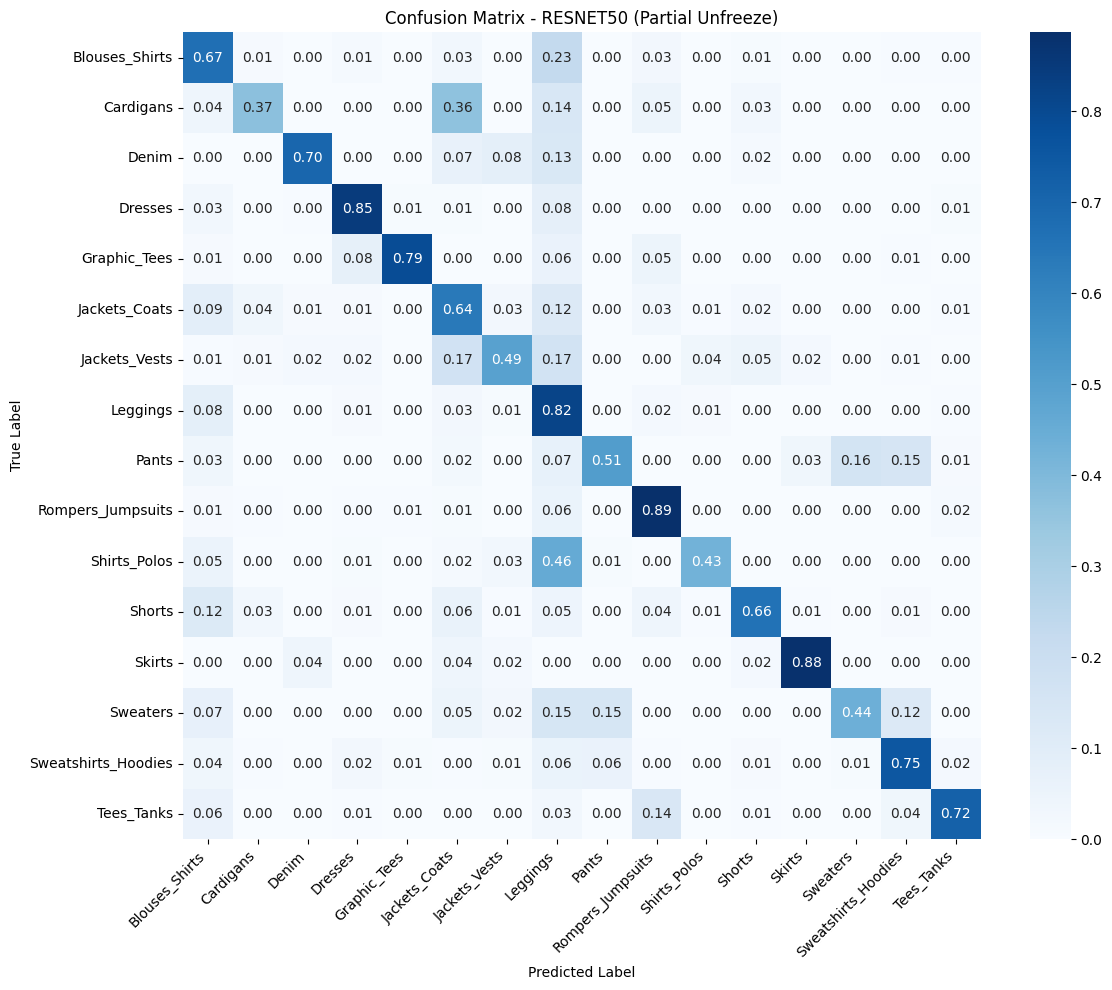

Metrics (Macro): Acc=0.7410, Prec=0.7271, Rec=0.6635, F1=0.6900


EVALUASI KLASIFIKASI: VGG19
Found 5174 validated image filenames belonging to 16 classes.
Memprediksi 5174 gambar validasi...
162/162 [==============================] - 20s 104ms/step

--- Classification Report ---
                     precision    recall  f1-score   support

     Blouses_Shirts       0.62      0.82      0.71       806
          Cardigans       0.41      0.42      0.41       137
              Denim       0.58      0.73      0.65        60
            Dresses       0.83      0.91      0.87       428
       Graphic_Tees       0.83      0.85      0.84       177
      Jackets_Coats       0.58      0.58      0.58       378
      Jackets_Vests       0.82      0.41      0.55       162
           Leggings       0.82      0.73      0.77      1446
              Pants       0.67      0.44      0.53        86
  Rompers_Jumpsuits       0.86      0.89      0.87       690
       Shirts_Polos       0.63      0.39      0

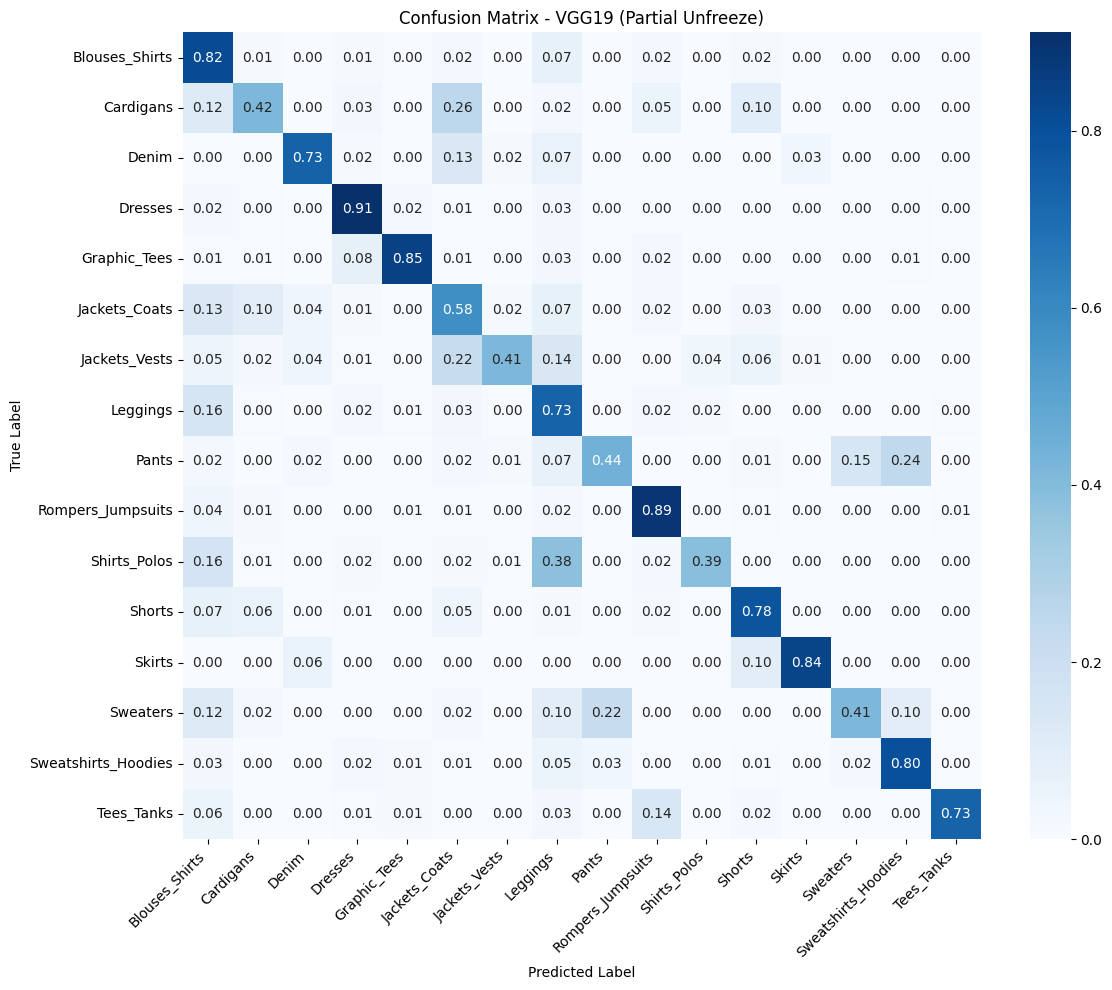

Metrics (Macro): Acc=0.7457, Prec=0.7148, Rec=0.6715, F1=0.6832


EVALUASI KLASIFIKASI: INCEPTIONV3
Found 5174 validated image filenames belonging to 16 classes.
Memprediksi 5174 gambar validasi...
162/162 [==============================] - 13s 72ms/step

--- Classification Report ---
                     precision    recall  f1-score   support

     Blouses_Shirts       0.67      0.68      0.67       806
          Cardigans       0.54      0.27      0.36       137
              Denim       0.68      0.72      0.70        60
            Dresses       0.85      0.84      0.85       428
       Graphic_Tees       0.85      0.80      0.82       177
      Jackets_Coats       0.61      0.61      0.61       378
      Jackets_Vests       0.62      0.47      0.54       162
           Leggings       0.73      0.79      0.76      1446
              Pants       0.65      0.48      0.55        86
  Rompers_Jumpsuits       0.78      0.91      0.84       690
       Shirts_Polos       0.61      0.47  

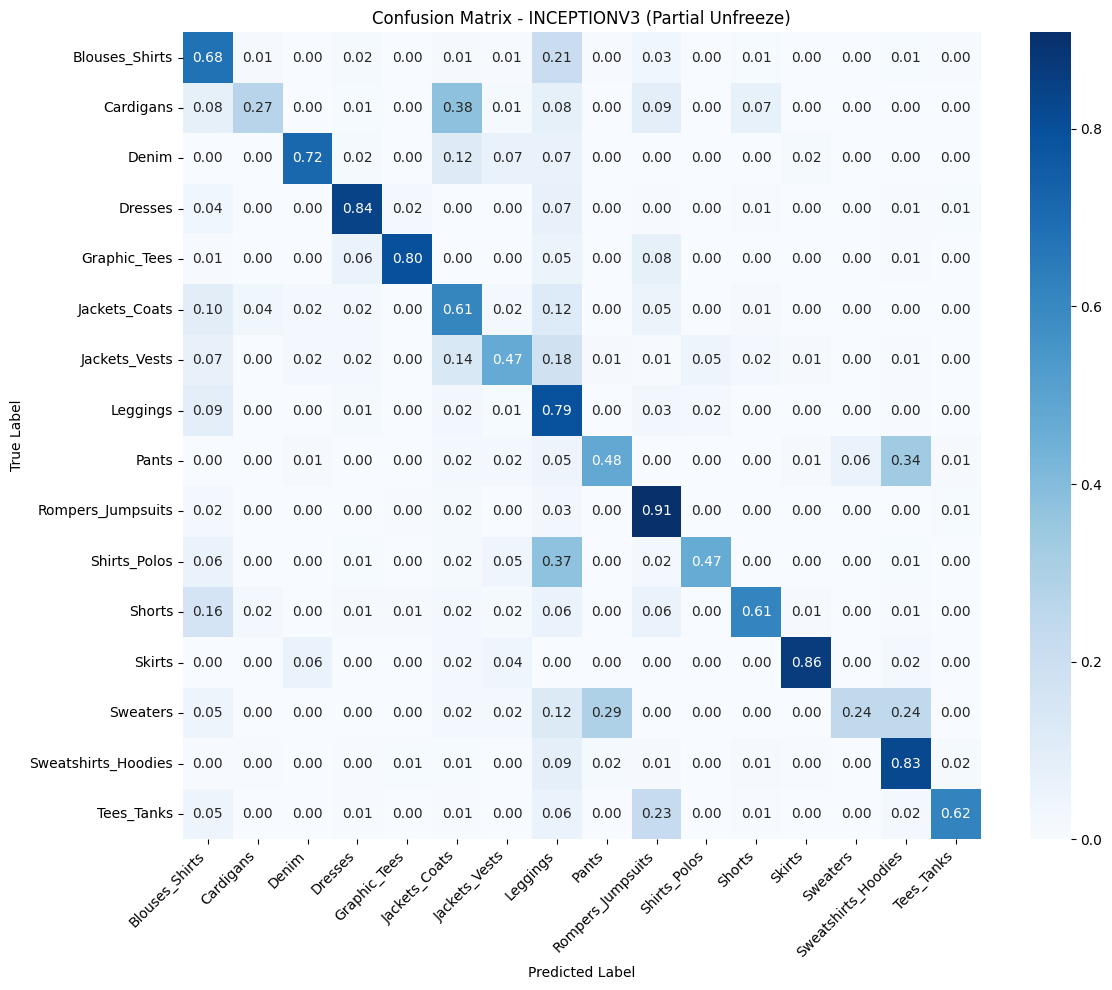

Metrics (Macro): Acc=0.7296, Prec=0.7132, Rec=0.6374, F1=0.6626


EVALUASI KLASIFIKASI: MOBILENETV3
Found 5174 validated image filenames belonging to 16 classes.
Memprediksi 5174 gambar validasi...
162/162 [==============================] - 5s 27ms/step

--- Classification Report ---
                     precision    recall  f1-score   support

     Blouses_Shirts       0.64      0.73      0.68       806
          Cardigans       0.48      0.38      0.42       137
              Denim       0.85      0.58      0.69        60
            Dresses       0.82      0.86      0.84       428
       Graphic_Tees       0.83      0.74      0.78       177
      Jackets_Coats       0.66      0.54      0.60       378
      Jackets_Vests       0.69      0.44      0.54       162
           Leggings       0.74      0.80      0.77      1446
              Pants       0.72      0.51      0.60        86
  Rompers_Jumpsuits       0.83      0.88      0.86       690
       Shirts_Polos       0.57      0.50   

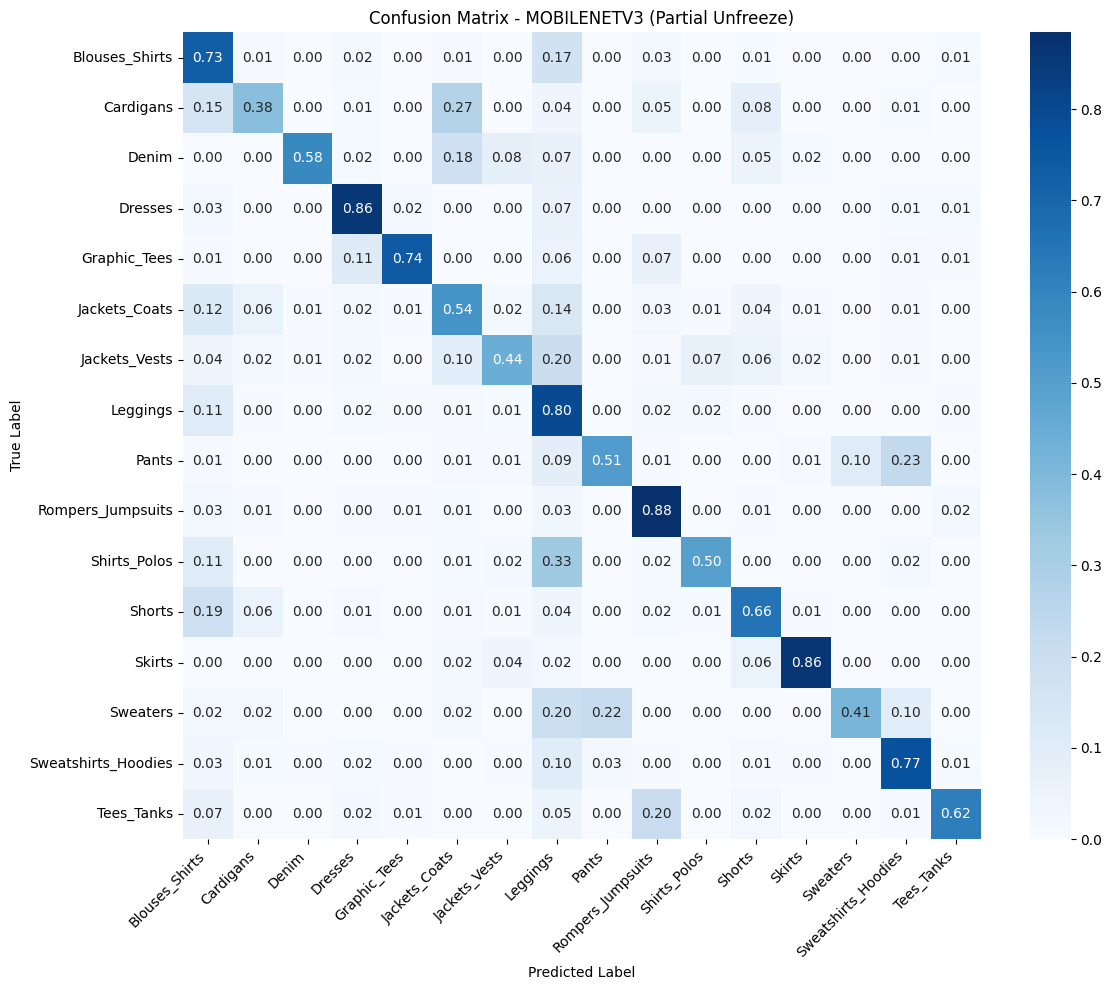

Metrics (Macro): Acc=0.7319, Prec=0.7186, Rec=0.6433, F1=0.6732


✅ Hasil evaluasi klasifikasi disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\partial unfreeze\hasil_evaluasi\partial_unfreeze_classification_results.csv
         Model  Accuracy  Macro Precision  Macro Recall  Macro F1-Score  \
0     resnet50  0.741013         0.727139      0.663485        0.690034   
1        vgg19  0.745651         0.714830      0.671528        0.683237   
2  inceptionv3  0.729610         0.713232      0.637450        0.662600   
3  mobilenetv3  0.731929         0.718600      0.643322        0.673153   

   Eval Time (s)  
0          12.19  
1          20.26  
2          12.72  
3           5.07  


In [4]:
# ─────────────────────────────────────────────
# CELL 3: Proses Evaluasi Klasifikasi Semua Model Partial Unfreeze
# ─────────────────────────────────────────────
eval_results = []

for m_name, cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*50}\nEVALUASI KLASIFIKASI: {m_name.upper()}\n{'='*50}")
    
    model_path = os.path.join(MODEL_DIR, f"{m_name}_partial_unfreeze.h5")
    if not os.path.exists(model_path):
        print(f"⚠️ Model weight {model_path} tidak ditemukan! Lewati...")
        continue
        
    model = build_eval_model(cfg, num_classes)
    model.load_weights(model_path)
    
    val_datagen = ImageDataGenerator(preprocessing_function=cfg['preprocess'])
    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col='full_path',
        y_col='category_str',
        target_size=cfg['input_size'],
        batch_size=BATCH_SIZE,
        class_mode='sparse',
        shuffle=False
    )
    
    print(f"Memprediksi {len(val_df)} gambar validasi...")
    start_time = time.time()
    preds = model.predict(val_generator)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = val_generator.classes
    eval_time = time.time() - start_time
    
    report = classification_report(true_classes, pred_classes, target_names=class_names, output_dict=True)
    report_text = classification_report(true_classes, pred_classes, target_names=class_names)
    print("\n--- Classification Report ---")
    print(report_text)
    
    # Save Report text ke file
    report_file = os.path.join(EVAL_DIR, f"{m_name}_classification_report.txt")
    with open(report_file, 'w') as f:
        f.write(f"=== CLASSIFICATION REPORT: {m_name.upper()} (Partial Unfreeze) ===\n\n")
        f.write(report_text)
    print(f"Report disimpan di: {report_file}")
    
    # ── Confusion Matrix Visualisasi (Render Inline di Notebook) ──
    cm = confusion_matrix(true_classes, pred_classes, normalize='true')
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {m_name.upper()} (Partial Unfreeze)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Simpan metrics makro
    acc = report['accuracy']
    macro_p = report['macro avg']['precision']
    macro_r = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']
    
    eval_results.append({
        'Model': m_name,
        'Accuracy': acc,
        'Macro Precision': macro_p,
        'Macro Recall': macro_r,
        'Macro F1-Score': macro_f1,
        'Eval Time (s)': round(eval_time, 2)
    })
    
    print(f"Metrics (Macro): Acc={acc:.4f}, Prec={macro_p:.4f}, Rec={macro_r:.4f}, F1={macro_f1:.4f}\n")

df_eval = pd.DataFrame(eval_results)
eval_csv_path = os.path.join(EVAL_DIR, 'partial_unfreeze_classification_results.csv')
df_eval.to_csv(eval_csv_path, index=False)
print(f"\n✅ Hasil evaluasi klasifikasi disimpan di: {eval_csv_path}")
print(df_eval)
